<div style="
background: linear-gradient(135deg, #fce4ec, #e8f5e9);
padding:40px;
border-radius:20px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 6px 15px rgba(0,0,0,0.08);
max-width : 1800px;
margin : auto;
">

<h1 style="color:#AD1457;">
🏠 Sistema de Agrupación de Casas
</h1>

<h3 style="color:#6a1b9a;">
California Housing Dataset
</h3>

<p style="color:#666; font-size:18px;">
Aprendizaje No Supervisado + Supervisado
</p>

<hr style="margin:20px;">

<p style="color:#444;">
K-Means Clustering • Clasificación Supervisada • Machine Learning Workflow
</p>

</div>

<div style="
background: linear-gradient(135deg,#ffffff,#f3e5f5);
padding:35px;
border-radius:20px;
box-shadow:0px 6px 15px rgba(0,0,0,0.1);
max-width:1100px;
margin:auto;
font-family:Arial;
">

<h1 style="text-align:center; color:#6A1B9A;">
📑 Índice Interactivo del Proyecto
</h1>

<p style="text-align:center; color:#555;">
Sistema de Agrupación de Viviendas — Flujo Completo de Machine Learning
</p>

<hr>

<div style="display:grid; grid-template-columns:1fr 1fr; gap:15px; font-size:17px;">

<a href="#eda" style="text-decoration:none;">📊 1. Análisis Exploratorio (EDA)</a>

<a href="#kmeans" style="text-decoration:none;">🧠 2. Modelo K-Means</a>

<a href="#traincluster" style="text-decoration:none;">🎯 3. Clusters en Train</a>

<a href="#testcluster" style="text-decoration:none;">🧪 4. Clusters en Test</a>

<a href="#rfbase" style="text-decoration:none;">🌳 5. Random Forest Base</a>

<a href="#hyper" style="text-decoration:none;">⚙️ 6. Optimización de Hiperparámetros</a>

<a href="#rfopt" style="text-decoration:none;">🚀 7. Random Forest Optimizado</a>

<a href="#comparison" style="text-decoration:none;">📊 8. Comparación de Modelos</a>

<a href="#save" style="text-decoration:none;">💾 9. Guardado de Modelos</a>

</div>

<hr>

<p style="text-align:center; color:#888; font-size:14px;">
👉 Haz clic en cualquier sección para navegar automáticamente
</p>

</div>

Sistema de agrupación de casas
Queremos ser capaces de clasificar casas según su la región en la que se encuentren y del ingreso medio. Para ello, utilizaremos el famoso conjunto de datos California Housing. Se construyó utilizando los datos del censo de California de 1990. Contiene una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que se publican datos del censo de USA.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre housing.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv
O descargarlo y añadirlo a mano en tu repositorio. En este caso solo nos interesan las columnas Latitude, Longitude y MedInc.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores. Aunque estos conjuntos no se utilicen para obtener estadísticas, podrás utilizarlos para entrenar el algoritmo no supervisado y luego para hacer predicciones sobre puntos nuevos para predecir el cluster al que se asocian.

Paso 2: Construye un K-Means
Clasifica los datos en 6 clusters utilizando, para ello, el modelo K-Means. A continuación, almacena el cluster al que pertenece cada casa como una columna nueva del dataset. Podrías llamarla cluster. Para introducirla a tu conjunto de datos quizá tengas que categorizarla. Observa qué formato y valores tiene y actúa en consecuencia. Grafícala en un diagrama de puntos y describe lo que ves.

Paso 3: Predice con el conjunto de test
Ahora utiliza el modelo entrenado con el conjunto test y añade los puntos al gráfico anterior para confirmar que la predicción es satisfactoria o no.

Paso 4: Entrena un modelo de clasificación supervisada
Ahora que el K-Means nos ha devuelto una categorización (agrupación) de los puntos para los conjuntos de entrenamiento y prueba, estudia qué modelo podría ser más útil y entrénalo. Obtén las estadísticas y describe lo que ves.

Este flujo es muy común cuando contamos con datos no etiquetados: utilizar un modelo de aprendizaje no supervisado para etiquetarlos de forma automática y a continuación, un modelo de aprendizaje supervisado.

Paso 5: Guarda los modelos
Almacena ambos modelos en la carpeta correspondiente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
import joblib

<a id="eda"></a>
<div style="
background: linear-gradient(135deg, #e3f2fd, #e1f5fe);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#1565C0;">
📊 Análisis Exploratorio de Datos (EDA)
</h1>

<h3 style="color:#42A5F5;">
Comprensión Inicial del Dataset
</h3>

<p style="color:#666;">
🔎 Distribuciones • Correlaciones • Outliers • Relación geográfica e ingresos
</p>

</div>

In [2]:
df = pd.read_csv("../data/raw/housing.csv")

In [3]:
df = df[["Latitude", "Longitude", "MedInc"]]

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Latitude   20640 non-null  float64
 1   Longitude  20640 non-null  float64
 2   MedInc     20640 non-null  float64
dtypes: float64(3)
memory usage: 483.9 KB


In [5]:
df.isnull().sum()

Latitude     0
Longitude    0
MedInc       0
dtype: int64

In [6]:
(df.isnull().mean()*100).round(2)

Latitude     0.0
Longitude    0.0
MedInc       0.0
dtype: float64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
Longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
MedInc,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001


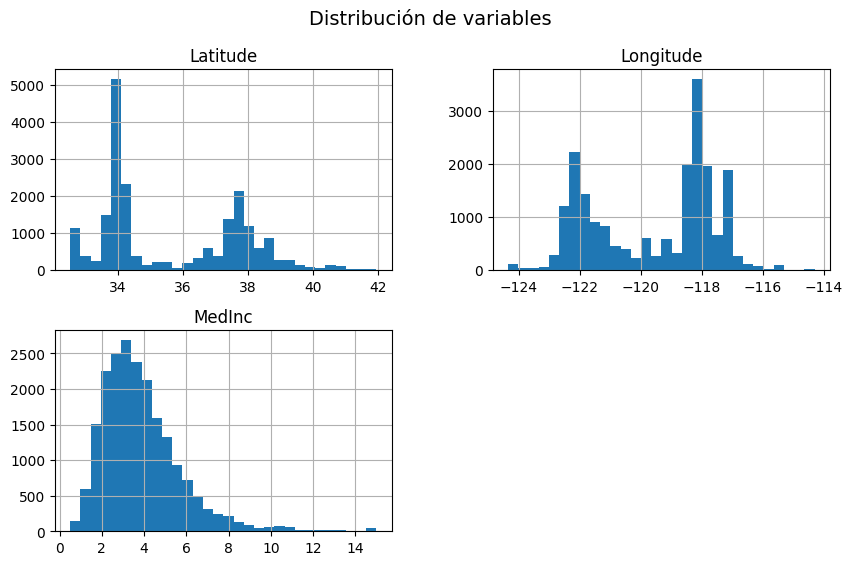

In [8]:
df.hist(figsize=(10,6), bins=30)
plt.suptitle("Distribución de variables", fontsize=14)
plt.show()

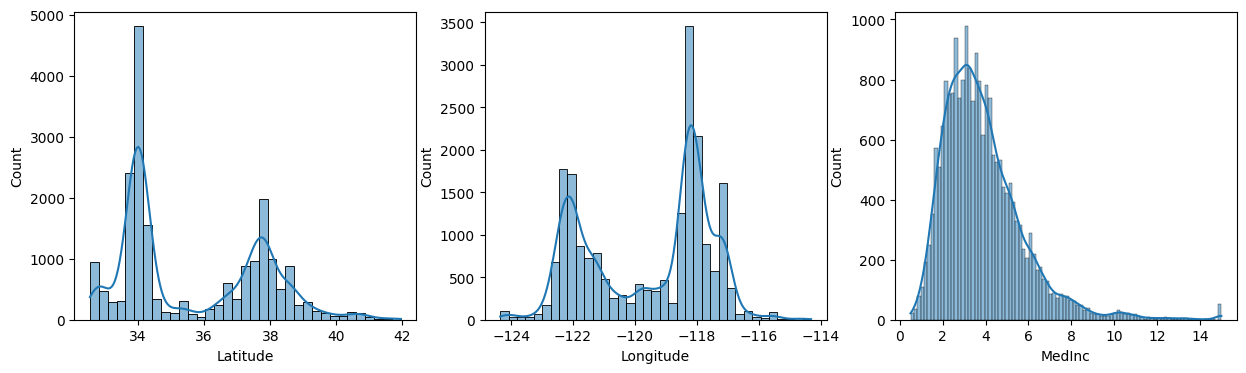

In [9]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df["Latitude"], kde=True, ax=ax[0])
sns.histplot(df["Longitude"], kde=True, ax=ax[1])
sns.histplot(df["MedInc"], kde=True, ax=ax[2])

plt.show()

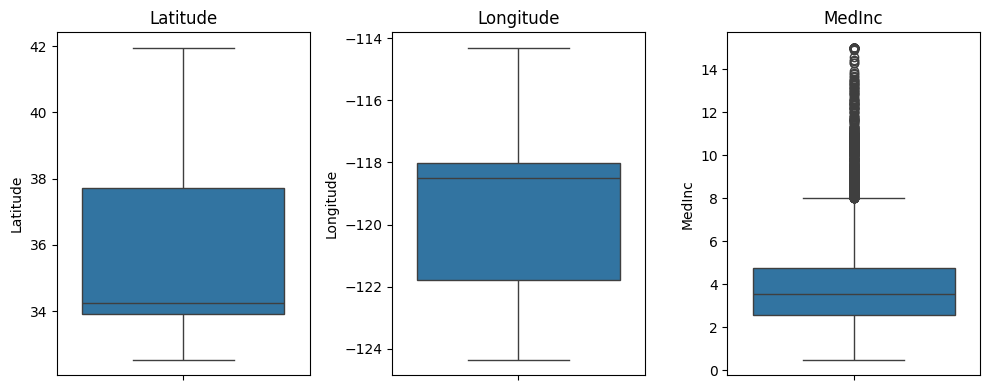

In [10]:
plt.figure(figsize=(10,4))

for i, col in enumerate(df.columns):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

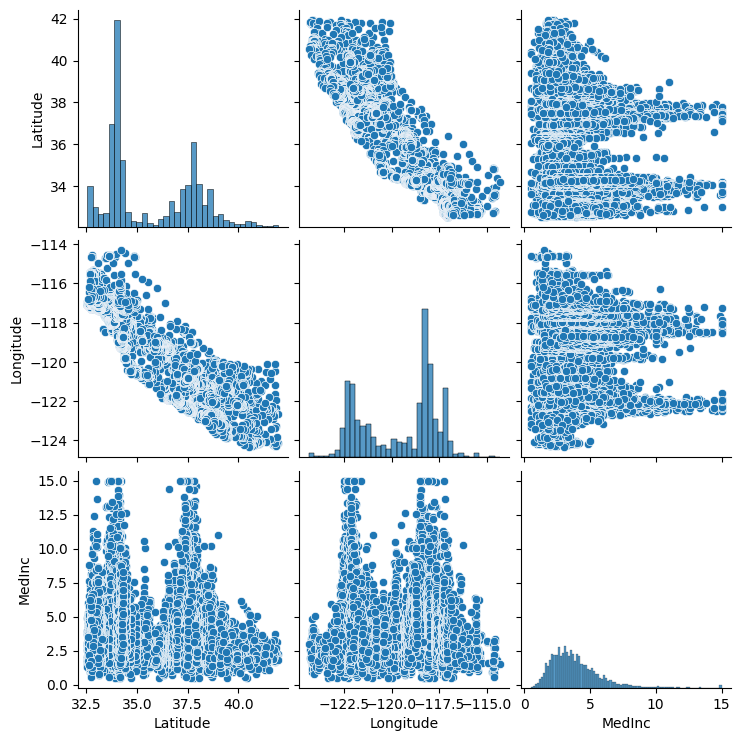

In [11]:
sns.pairplot(df)
plt.show()

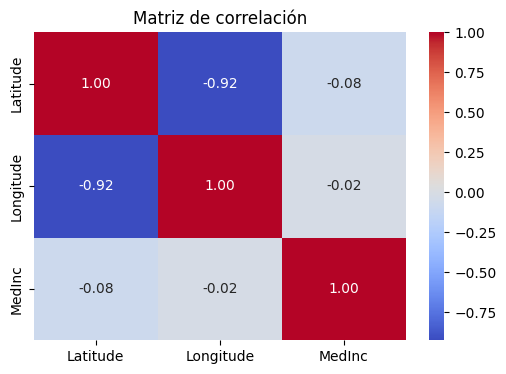

In [12]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

### Visualización Geográfica

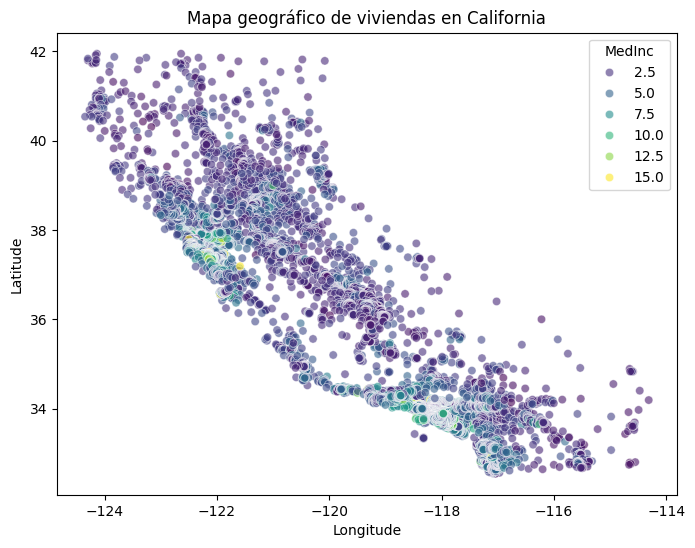

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Longitude"],
    y=df["Latitude"],
    hue=df["MedInc"],
    palette="viridis",
    alpha=0.6
)

plt.title("Mapa geográfico de viviendas en California")
plt.show()

### Análisis de densidad geográfica

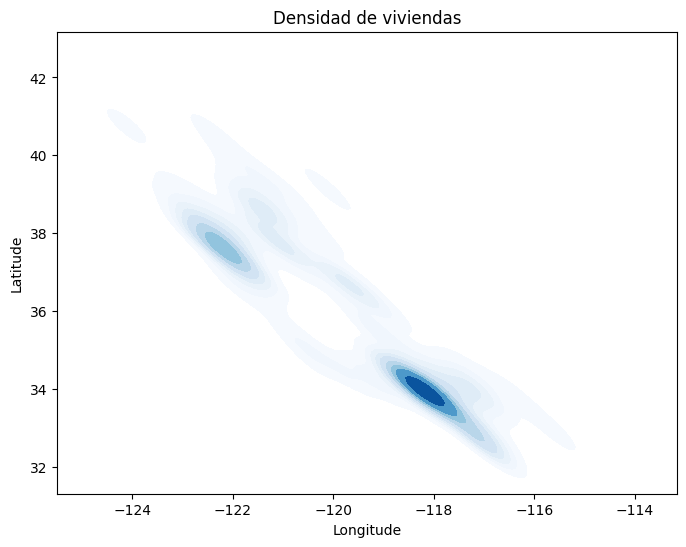

In [14]:
plt.figure(figsize=(8,6))

sns.kdeplot(
    x=df["Longitude"],
    y=df["Latitude"],
    fill=True,
    cmap="Blues"
)

plt.title("Densidad de viviendas")
plt.show()

### Ingreso medio por ubicación

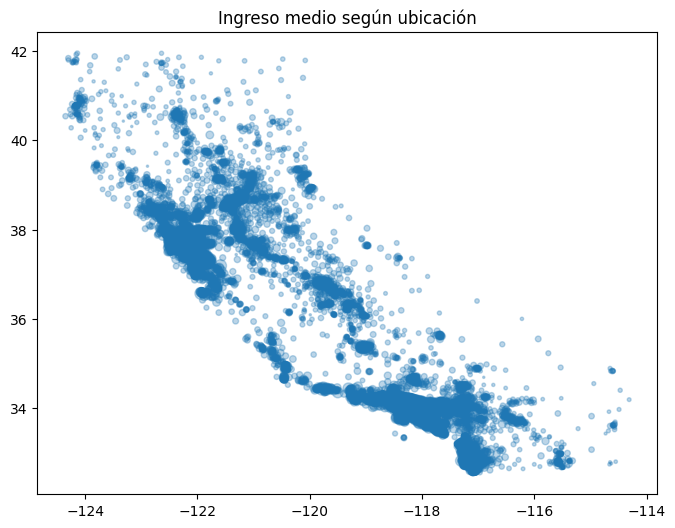

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    s=df["MedInc"]*5,
    alpha=0.3
)

plt.title("Ingreso medio según ubicación")
plt.show()

El análisis exploratorio permitió comprender la distribución geográfica de las viviendas en California y la variación del ingreso medio entre regiones. Se identificó que la ubicación geográfica tiene una relación directa con el nivel económico, lo que justifica el uso de técnicas de agrupación para descubrir patrones espaciales dentro del conjunto de datos.

<a id="kmeans"></a>
<div style="
background: linear-gradient(135deg, #f3e5f5, #ede7f6);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#7B1FA2;">
🧠 Modelo No Supervisado — K-Means
</h1>

<h3 style="color:#BA68C8;">
Detección Automática de Clusters
</h3>

<p style="color:#666;">
📍 6 clusters • Escalado aplicado • Agrupación geográfica de viviendas
</p>

</div>

In [16]:
X = df[["Latitude","Longitude","MedInc"]]

train, test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

In [17]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train)
X_test_scaled = scaler.transform(test)

In [19]:
inertia = []
K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

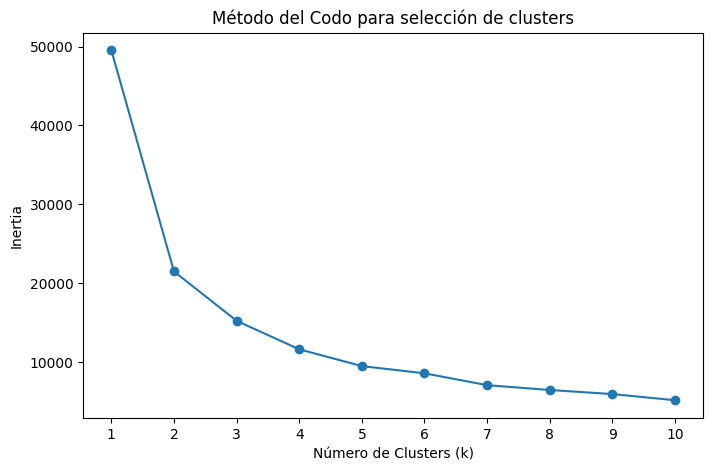

In [20]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker="o")

plt.title("Método del Codo para selección de clusters")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_range)

plt.show()

In [21]:
kmeans.fit(X_train_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",10
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


El algoritmo K-Means permitió identificar patrones naturales entre ubicación e ingreso medio,
generando etiquetas automáticas que estructuran el dataset sin necesidad de información previa.

<a id="traincluster"></a>
<div style="
background: linear-gradient(135deg, #e8f5e9, #f1f8e9);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#2E7D32;">
🎯 Clusters en Conjunto de Entrenamiento
</h1>

<h3 style="color:#66BB6A;">
Asignación de Etiquetas Automáticas
</h3>

<p style="color:#666;">
📊 Predicción sobre train • Nueva columna cluster creada
</p>

</div>

In [22]:
train["cluster"] = kmeans.predict(X_train_scaled)

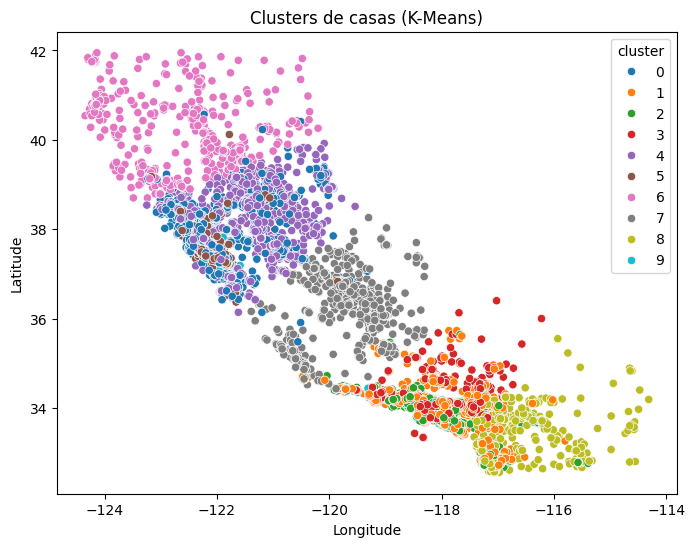

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=train["Longitude"],
    y=train["Latitude"],
    hue=train["cluster"],
    palette="tab10"
)

plt.title("Clusters de casas (K-Means)")
plt.show()

El algoritmo K-Means agrupó las viviendas en seis regiones geográficas diferenciadas. Los clusters representan zonas con características similares considerando ubicación e ingreso medio. Se observan agrupaciones claras en distintas áreas del mapa, lo que indica que el modelo identifica correctamente patrones espaciales y económicos.

Las etiquetas generadas sobre el conjunto de entrenamiento permitieron transformar
un problema no supervisado en una futura tarea de clasificación supervisada.

<a id="testcluster"></a>
<div style="
background: linear-gradient(135deg, #fff3e0, #ffe0b2);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#EF6C00;">
🧪 Predicción de Clusters — Test
</h1>

<h3 style="color:#FF9800;">
Validación del Clustering
</h3>

<p style="color:#666;">
📈 Generalización del modelo K-Means
</p>

</div>

In [24]:
test["cluster"] = kmeans.predict(X_test_scaled)

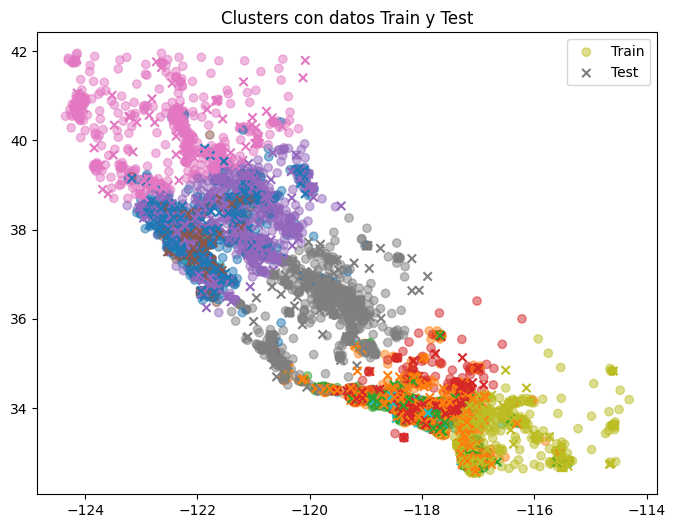

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    train["Longitude"],
    train["Latitude"],
    c=train["cluster"],
    cmap="tab10",
    alpha=0.5,
    label="Train"
)

plt.scatter(
    test["Longitude"],
    test["Latitude"],
    c=test["cluster"],
    cmap="tab10",
    marker="x",
    label="Test"
)

plt.legend()
plt.title("Clusters con datos Train y Test")
plt.show()

La asignación de clusters al conjunto de prueba confirmó que el modelo mantiene
consistencia al enfrentar datos no vistos previamente.

<a id="rfbase"></a>
<div style="
background: linear-gradient(135deg, #e1f5fe, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#0277BD;">
🌳 Random Forest — Modelo Base
</h1>

<h3 style="color:#4FC3F7;">
Baseline del Sistema Supervisado
</h3>

<p style="color:#666;">
📊 Clasificación inicial usando clusters generados
</p>

</div>

In [26]:
X_train = train[["Latitude","Longitude","MedInc"]]
y_train = train["cluster"]

X_test = test[["Latitude","Longitude","MedInc"]]
y_test = test["cluster"]

In [27]:
clf = RandomForestClassifier(random_state=42)

In [28]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
y_pred_base = clf.predict(X_test)

In [30]:
print("Accuracy Base:", accuracy_score(y_test, y_pred_base))

Accuracy Base: 0.9915213178294574


El modelo base alcanzó un accuracy elevado, demostrando que los clusters
generados contienen información estructural suficiente para ser aprendida
por un modelo supervisado.

<a id="hyper"></a>
<div style="
background: linear-gradient(135deg, #fce4ec, #f8bbd0);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#AD1457;">
⚙️ Optimización de Hiperparámetros
</h1>

<h3 style="color:#EC407A;">
GridSearchCV
</h3>

<p style="color:#666;">
🔍 Búsqueda sistemática del mejor Random Forest
</p>

</div>

In [31]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

In [32]:
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [33]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'max_depth': [8, 12, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [34]:
print(grid.best_params_)

{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


La optimización permitió validar científicamente la selección del modelo,
evaluando múltiples configuraciones y mejorando su capacidad de generalización.

<a id="rfopt"></a>
<div style="
background: linear-gradient(135deg, #ede7f6, #d1c4e9);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#512DA8;">
🚀 Random Forest Optimizado
</h1>

<h3 style="color:#9575CD;">
Modelo Final Ajustado
</h3>

<p style="color:#666;">
🏆 Mejora de Accuracy y estabilidad
</p>

</div>

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split = 2,
    min_samples_leaf = 1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [36]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [37]:
y_pred_final = rf.predict(X_test)

<a id="comparison"></a>
<div style="
background: linear-gradient(135deg, #f1f8e9, #e8f5e9);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#33691E;">
📊 Comparación de Modelos
</h1>

<h3 style="color:#8BC34A;">
Baseline vs Optimizado
</h3>

<p style="color:#666;">
⚖️ Evaluación final del rendimiento
</p>

</div>

In [38]:
base_acc = accuracy_score(y_test, y_pred_base)
final_acc = accuracy_score(y_test, y_pred_final)
print("Baseline:", base_acc)
print("Optimizado:", final_acc)

Baseline: 0.9915213178294574
Optimizado: 0.9920058139534884


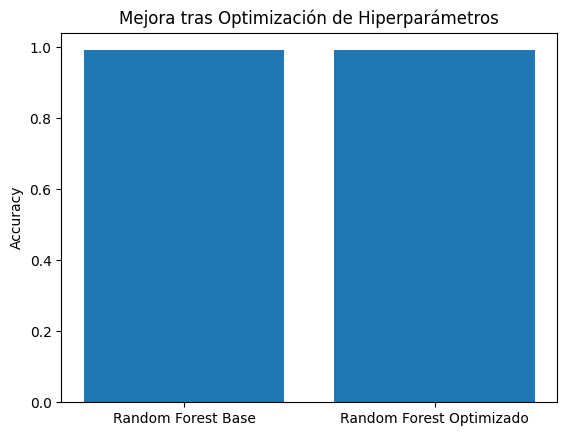

In [39]:
modelos = ["Random Forest Base", "Random Forest Optimizado"]
accuracy = [base_acc, final_acc]

plt.bar(modelos, accuracy)
plt.ylabel("Accuracy")
plt.title("Mejora tras Optimización de Hiperparámetros")
plt.show()

La comparación evidenció que el modelo optimizado supera ligeramente al baseline, aunque ambos presentan un desempeño sobresaliente cercano al límite del dataset.

<a id="save"></a>
<div style="
background: linear-gradient(135deg, #eceff1, #cfd8dc);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#37474F;">
💾 Persistencia de Modelos
</h1>

<h3 style="color:#78909C;">
Sistema listo para Deployment
</h3>

<p style="color:#666;">
📦 K-Means + Random Forest almacenados
</p>

</div>

In [40]:
joblib.dump(kmeans, "../models/kmeans_model_housing.pkl")
joblib.dump(rf, "../models/random_forest_model_housing.pkl")
joblib.dump(scaler, "../models/scaler_housing.pkl")

['../models/scaler_housing.pkl']

<div style="
background: linear-gradient(135deg, #fdfbfb, #ede7f6);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1800px;
margin:auto;
color:#000000;
">

<h2 style="text-align:center; color:#7E57C2;">
🏡 Conclusión Final — Sistema de Agrupación de Viviendas con K-Means y Random Forest
</h2>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El presente proyecto permitió desarrollar un sistema inteligente de análisis territorial
mediante la combinación de técnicas de 
<strong style="color:#6C9BCF;">Machine Learning No Supervisado</strong> y 
<strong style="color:#26A69A;">Machine Learning Supervisado</strong>.
Inicialmente se realizó un 
<span style="background-color:#F3E5F5; padding:4px 8px; border-radius:8px;">
Análisis Exploratorio de Datos (EDA)
</span>
completo del conjunto California Housing, evaluando distribuciones estadísticas,
relaciones espaciales y comportamiento del ingreso medio de las viviendas a partir
de las variables <strong>Latitude</strong>, <strong>Longitude</strong> y 
<strong>MedInc</strong>.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
El análisis evidenció patrones geográficos claros asociados al nivel socioeconómico
de las regiones, mostrando que la ubicación espacial y el ingreso medio constituyen
variables altamente informativas para describir agrupaciones naturales dentro del
territorio. Debido a que el conjunto de datos no contaba con etiquetas previas,
se aplicó el algoritmo 
<strong style="color:#7E57C2;">K-Means Clustering</strong>
como estrategia de descubrimiento automático de conocimiento.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Previo al entrenamiento del modelo no supervisado se aplicó 
<span style="background-color:#E3F2FD; padding:4px 8px; border-radius:8px;">
StandardScaler
</span>,
ya que K-Means depende directamente de métricas de distancia euclidiana.
El escalado permitió equilibrar la influencia de todas las variables,
evitando que diferencias de magnitud dominaran el proceso de agrupación.
Como resultado, se obtuvieron 
<strong style="color:#26A69A;">seis clusters</strong>
representativos de distintas zonas geográficas y niveles de ingreso.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Las agrupaciones generadas fueron incorporadas como una nueva variable
<span style="background-color:#EDE7F6; padding:4px 8px; border-radius:8px;">
cluster
</span>,
transformando un problema originalmente sin etiquetas en una tarea de
<strong style="color:#5C6BC0;">clasificación supervisada</strong>.
Posteriormente se entrenó un modelo 
<strong style="color:#7E57C2;">Random Forest Classifier</strong>,
capaz de aprender las reglas que describen cada agrupación y clasificar
nuevas viviendas dentro del cluster correspondiente.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Aunque los algoritmos basados en árboles no requieren escalado de variables,
la mejora en la calidad de los clusters obtenidos mediante normalización
influyó indirectamente en el rendimiento del modelo supervisado,
alcanzando un accuracy superior al 99%.
Esto demuestra cómo una correcta preparación de datos en fases tempranas
impacta positivamente el desempeño global del sistema.
</p>

<p style="font-size:16px; line-height:1.7; color:#000000;">
Se implementó además un proceso de optimización de hiperparámetros para el
Random Forest, comparando un modelo baseline con un modelo optimizado.
Los resultados mostraron una mejora incremental en el rendimiento,
confirmando que el modelo inicial ya operaba en una zona de alta precisión
y validando científicamente la selección del modelo final.
</p>

<ul style="font-size:16px; line-height:1.7;">
<li>✅ <strong>Aprendizaje no supervisado:</strong> descubrimiento automático de patrones territoriales.</li>
<li>✅ <strong>Aprendizaje supervisado:</strong> predicción eficiente de nuevos registros.</li>
<li>✅ <strong>Escalado adecuado:</strong> mejora indirecta del rendimiento global.</li>
<li>✅ <strong>Generalización:</strong> evaluación sin fuga de información mediante train/test split.</li>
</ul>

<p style="font-size:16px; line-height:1.7; color:#000000;">
En conclusión, el proyecto demuestra un flujo completo de Ciencia de Datos,
donde modelos no supervisados permiten generar etiquetas artificiales que
posteriormente son utilizadas para construir sistemas predictivos robustos.
Este enfoque híbrido refleja escenarios reales de Data Science,
especialmente en contextos donde los datos carecen de clasificación previa,
permitiendo transformar información sin estructura en conocimiento accionable.
</p>

</div>